## 1. Import Libraries

In [21]:
# Loads all libraries: pandas/numpy for data, matplotlib/seaborn for plots,
# statsmodels for regression/ANOVA/MANOVA/VIF, scipy.stats for t-tests.
# Result: No output — libraries loaded, global plot style set.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Statistical libraries (same as taught in class)
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.multivariate.manova import MANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

## 2. Load & Combine NSE Stock Data

NSE CSV quirks we handle:
- BOM character at the start → `encoding='utf-8-sig'`
- Numbers with comma separators (e.g. `2,581.50`) → `thousands=','`
- Date in `17-Apr-2026` format → parsed with `%d-%b-%Y`
- Descending date order → sorted ascending after combining

In [22]:
# Reads all 9 NSE CSV files, tags each row with its Ticker and Sector,
# and stacks them into one DataFrame called df.
# Result: Each file loaded with ~247 rows, combined = 2223 rows × 16 cols.
# 📁 Path to your folder containing the 9 NSE CSVs
# Change this path to wherever your ssdi_project folder is located
FOLDER = r"C:\Users\ACER\OneDrive - Shri Vile Parle Kelavani Mandal\Desktop\ssdi_project"
# On Mac/Linux, use: FOLDER = "/Users/YourName/Desktop/ssdi_project"

# Mapping: ticker → filename → sector
files = {
    'TCS':       'Quote-Equity-TCS-EQ-19-04-2025-19-04-2026.csv',
    'INFY':      'Quote-Equity-INFY-EQ-19-04-2025-19-04-2026.csv',
    'WIPRO':     'Quote-Equity-WIPRO-EQ-19-04-2025-19-04-2026.csv',
    'HDFCBANK':  'Quote-Equity-HDFCBANK-EQ-19-04-2025-19-04-2026.csv',
    'ICICIBANK': 'Quote-Equity-ICICIBANK-EQ-19-04-2025-19-04-2026.csv',
    'SBIN':      'Quote-Equity-SBIN-EQ-19-04-2025-19-04-2026.csv',
    'SUNPHARMA': 'Quote-Equity-SUNPHARMA-EQ-19-04-2025-19-04-2026.csv',
    'CIPLA':     'Quote-Equity-CIPLA-EQ-19-04-2025-19-04-2026.csv',
    'DRREDDY':   'Quote-Equity-DRREDDY-EQ-19-04-2025-19-04-2026.csv',
}

sector_map = {
    'TCS':'IT', 'INFY':'IT', 'WIPRO':'IT',
    'HDFCBANK':'Banking', 'ICICIBANK':'Banking', 'SBIN':'Banking',
    'SUNPHARMA':'Pharma', 'CIPLA':'Pharma', 'DRREDDY':'Pharma'
}

all_dfs = []
for ticker, fname in files.items():
    path = os.path.join(FOLDER, fname)
    temp = pd.read_csv(path, encoding='utf-8-sig', thousands=',')
    temp.columns = temp.columns.str.strip()   # remove extra whitespace in col names
    temp['Ticker'] = ticker
    temp['Sector'] = sector_map[ticker]
    all_dfs.append(temp)
    print(f"Loaded {ticker}: {len(temp)} rows")

df = pd.concat(all_dfs, ignore_index=True)
print(f"\nCombined dataset: {df.shape[0]} rows × {df.shape[1]} columns")

Loaded TCS: 247 rows
Loaded INFY: 247 rows
Loaded WIPRO: 247 rows
Loaded HDFCBANK: 247 rows
Loaded ICICIBANK: 247 rows
Loaded SBIN: 247 rows
Loaded SUNPHARMA: 247 rows
Loaded CIPLA: 247 rows
Loaded DRREDDY: 247 rows

Combined dataset: 2223 rows × 16 columns


In [23]:
# Converts DATE from text to real datetime, renames OHLC columns to Title-case,
# sorts by Ticker + Date, and keeps only the 8 columns we actually need.
# Result: Clean DataFrame of 2223 rows × 8 columns.
# Clean up the combined dataframe
df['DATE'] = pd.to_datetime(df['DATE'], format='%d-%b-%Y')

# Rename key columns to cleaner names
df = df.rename(columns={
    'OPEN': 'Open',
    'HIGH': 'High',
    'LOW':  'Low',
    'CLOSE':'Close',
    'VOLUME':'Volume'
})

# Sort by ticker + date (ascending)
df = df.sort_values(['Ticker', 'DATE']).reset_index(drop=True)

# Keep only the columns we need
df = df[['DATE', 'Ticker', 'Sector', 'Open', 'High', 'Low', 'Close', 'Volume']]

df

,DATE,Ticker,Sector,Open,High,Low,Close,Volume
0,2025-04-21,CIPLA,Pharma,1525.00,1525.00,1505.00,1511.10,570266
1,2025-04-22,CIPLA,Pharma,1514.90,1534.70,1502.70,1528.20,954974
2,2025-04-23,CIPLA,Pharma,1533.00,1539.00,1516.00,1533.70,819016
3,2025-04-24,CIPLA,Pharma,1533.70,1556.00,1524.90,1551.70,1590469
4,2025-04-25,CIPLA,Pharma,1556.00,1566.70,1513.50,1525.90,1353813
...,...,...,...,...,...,...,...,...
2218,2026-04-10,WIPRO,IT,208.70,208.70,200.62,204.88,51219565
2219,2026-04-13,WIPRO,IT,203.01,203.40,200.31,202.97,21930624
2220,2026-04-15,WIPRO,IT,206.50,210.49,205.10,209.75,27890080
2221,2026-04-16,WIPRO,IT,212.98,212.98,208.21,210.26,36305074


In [24]:
# Sanity check: prints dataset size, rows per sector, rows per ticker, missing values.
# Result: 2223 rows total, 741 per sector (balanced), 247 per ticker, 0 missing values.
print("Shape:", df.shape)
print("\nRows per sector:")
print(df['Sector'].value_counts())
print("\nRows per ticker:")
print(df['Ticker'].value_counts())
print("\nMissing values:", df.isnull().sum().sum())

Shape: (2223, 8)

Rows per sector:
Sector
Pharma     741
Banking    741
IT         741
Name: count, dtype: int64

Rows per ticker:
Ticker
CIPLA        247
DRREDDY      247
HDFCBANK     247
ICICIBANK    247
INFY         247
SBIN         247
SUNPHARMA    247
TCS          247
WIPRO        247
Name: count, dtype: int64

Missing values: 0


## 3. Create Derived Variables

Two new features for our analysis:
- **Daily_Return** = (Close − Open) / Open × 100  → percentage gain/loss in a day
- **Daily_Range_Pct** = (High − Low) / Open × 100  → intraday volatility

In [25]:
# Creates two new features from existing columns:
#   Daily_Return    = (Close - Open)/Open * 100  → intraday % gain/loss
#   Daily_Range_Pct = (High  - Low )/Open * 100  → intraday % swing (volatility)
# Result: 2 new columns visible in df.head().
df['Daily_Return']   = (df['Close'] - df['Open']) / df['Open'] * 100
df['Daily_Range_Pct'] = (df['High']  - df['Low'])  / df['Open'] * 100

df.head()

,DATE,Ticker,Sector,Open,High,Low,Close,Volume,Daily_Return,Daily_Range_Pct
0,2025-04-21,CIPLA,Pharma,1525.0,1525.0,1505.0,1511.1,570266,-0.911475,1.311475
1,2025-04-22,CIPLA,Pharma,1514.9,1534.7,1502.7,1528.2,954974,0.877946,2.112351
2,2025-04-23,CIPLA,Pharma,1533.0,1539.0,1516.0,1533.7,819016,0.045662,1.500326
3,2025-04-24,CIPLA,Pharma,1533.7,1556.0,1524.9,1551.7,1590469,1.173632,2.027776
4,2025-04-25,CIPLA,Pharma,1556.0,1566.7,1513.5,1525.9,1353813,-1.934447,3.419023


## 4. Exploratory Data Analysis

In [26]:
# Groups by Sector and shows the mean of every numeric column.
# Result: IT has the highest prices, Banking has the highest Volumes,
# all 3 sectors have near-zero average returns but differing volatility.
# Summary statistics per sector
df.groupby('Sector')[['Open','High','Low','Close','Volume','Daily_Return','Daily_Range_Pct']].mean().round(3)

,Open,High,Low,Close,Volume,Daily_Return,Daily_Range_Pct
Sector,,,,,,,
Banking,1206.529,1215.969,1197.426,1206.721,1.518724e+07,0.025,1.577
IT,1615.679,1629.049,1600.241,1613.982,8.020620e+06,-0.087,1.880
Pharma,1474.720,1487.472,1460.279,1474.257,1.915249e+06,-0.025,1.855


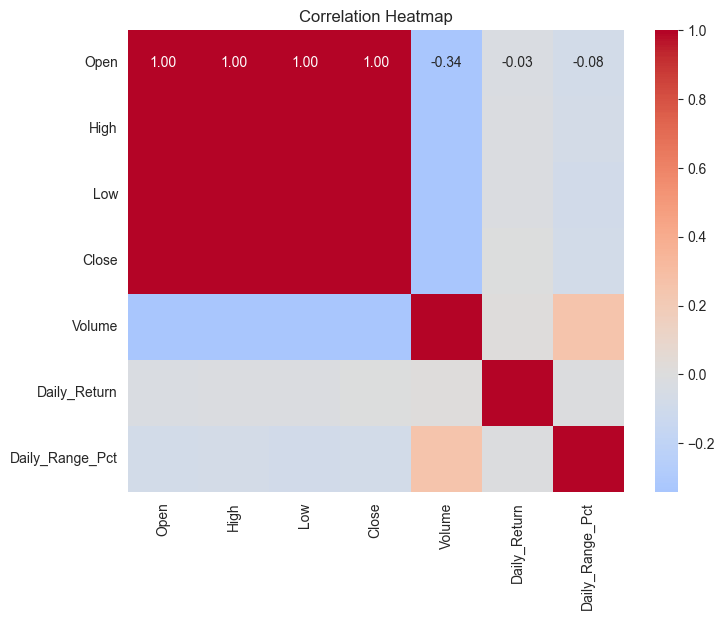

In [27]:
# Plots a correlation heatmap of all numeric columns.
# Result: Open/High/Low/Close are all ~1.00 correlated with each other — a
# first hint of multicollinearity, which VIF later confirms.
# 4.1 — Correlation heatmap of numeric variables
plt.figure(figsize=(8,6))
corr = df[['Open','High','Low','Close','Volume','Daily_Return','Daily_Range_Pct']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Correlation Heatmap')
plt.show()

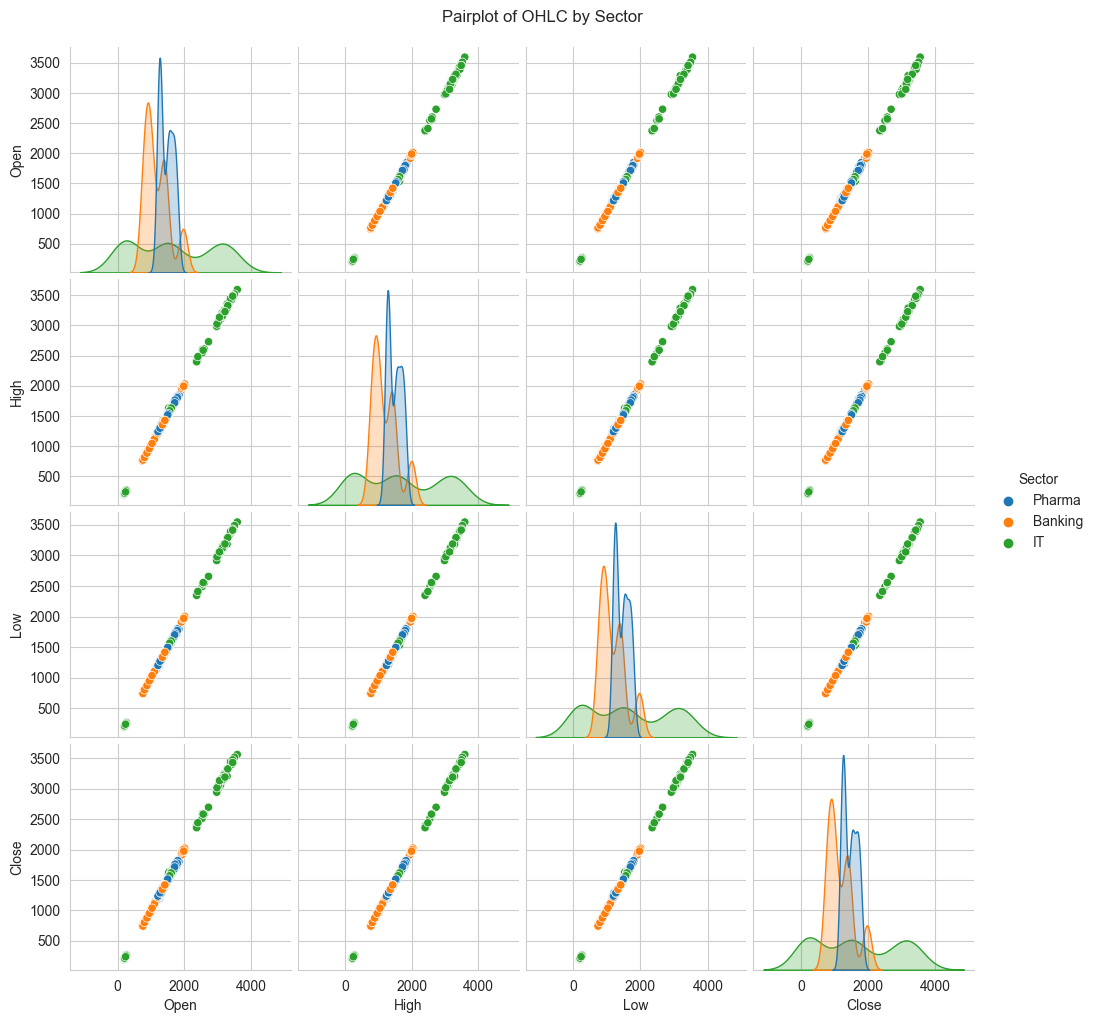

In [28]:
# Takes 500 random rows and draws scatter-plots for every pair of OHLC variables,
# coloured by Sector. diag_kind='kde' puts a density curve on the diagonal.
# Result: Sectors form visually separate price-level clusters.
# 4.2 — Pairplot of OHLC variables (sampled for speed)
# Take a random sample of 500 rows (for speed) and draw a grid of scatter-plots for every pair of OHLC variables.
# Points are coloured by Sector (hue) so we can visually see if sectors cluster into separate price regions.
# diag_kind='kde' replaces the diagonal (where a variable meets itself) with a smooth density curve instead of a histogram.
# The suptitle adds an overall title above the whole grid, with y=1.02 lifting it slightly so it doesn't overlap the plots.
sns.pairplot(df.sample(500, random_state=1)[['Open','High','Low','Close','Sector']],
             hue='Sector', diag_kind='kde')
plt.suptitle('Pairplot of OHLC by Sector', y=1.02)
plt.show()

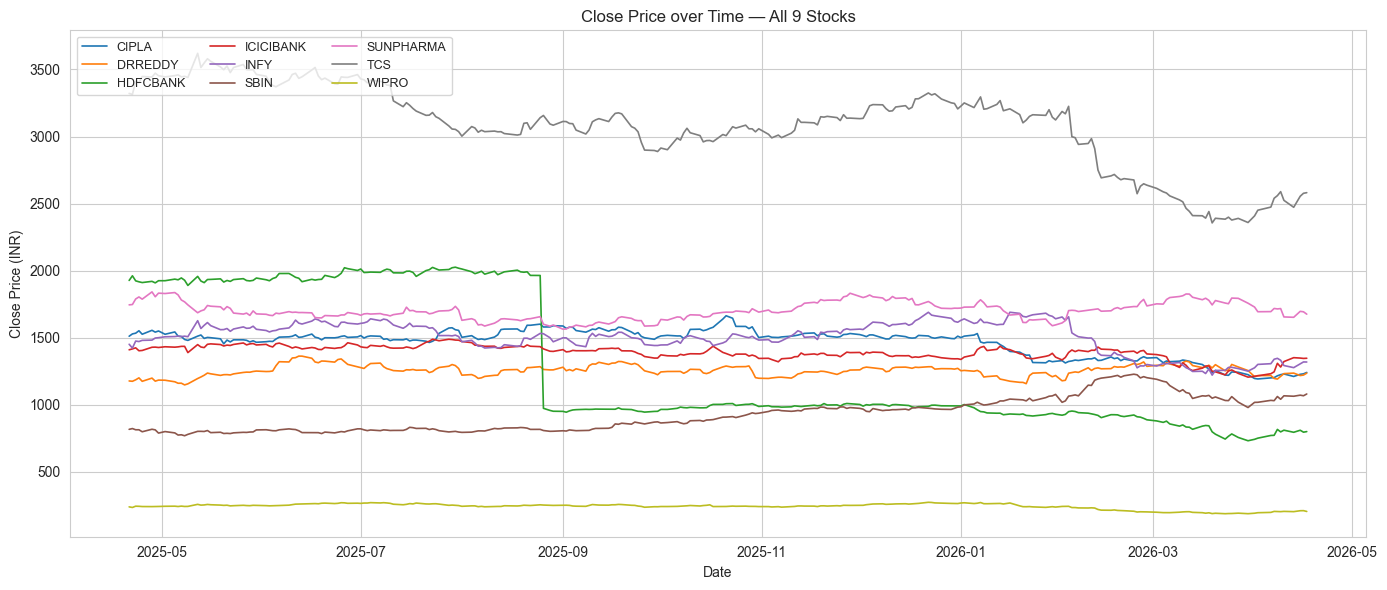

In [29]:
# Plots Close price over time for all 9 stocks on one chart.
# Result: Visual trajectory of each stock over the year — some trended up,
# some drifted down, useful for spotting outlier events.
# 4.3 — Close price over time per ticker
plt.figure(figsize=(14,6))
for ticker in df['Ticker'].unique():
    sub = df[df['Ticker']==ticker]
    plt.plot(sub['DATE'], sub['Close'], label=ticker, linewidth=1.2)
plt.title('Close Price over Time — All 9 Stocks')
plt.xlabel('Date'); plt.ylabel('Close Price (INR)')
plt.legend(loc='upper left', ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

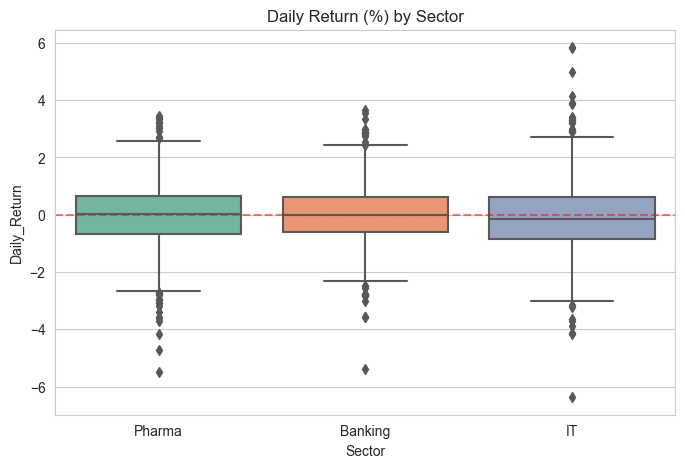

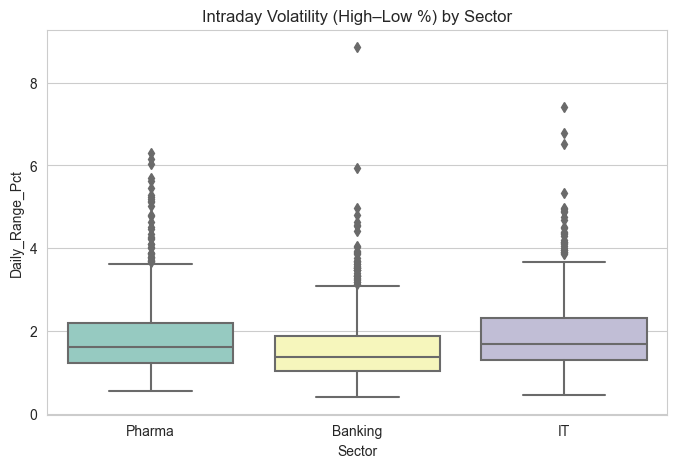

In [30]:
# Two boxplots: Daily Return by Sector (top) and Daily_Range_Pct by Sector (bottom).
# Result: Return boxes overlap heavily (means are similar), but volatility boxes
# differ — Banking box is clearly the tightest (least volatile sector).
# 4.4 — Boxplot: Daily Return by Sector
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Sector', y='Daily_Return', palette='Set2')
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.title('Daily Return (%) by Sector')
plt.show()

# 4.5 — Boxplot: Intraday Volatility by Sector
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Sector', y='Daily_Range_Pct', palette='Set3')
plt.title('Intraday Volatility (High–Low %) by Sector')
plt.show()

## 5. Linear Regression
**Goal:** Predict `Close` price from `Open`, `High`, `Low`, `Volume`.

Same syntax as your class notebook:
```python
smf.ols("y ~ x1 + x2", data=df).fit().summary()
```

In [31]:
# Simple linear regression: Close = α + β·Open.
# Result: R² ≈ 1.000, β ≈ 1.00, p-value ≈ 0 — Close is almost identical to Open.
# Open is an extremely strong, significant predictor on its own.
# 5.1 — Simple linear regression: Close ~ Open
lm_simple = smf.ols('Close ~ Open', data=df).fit()
lm_simple.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Close   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 3.758e+06
Date:                Sun, 19 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:54:03   Log-Likelihood:                -9582.4
No. Observations:                2223   AIC:                         1.917e+04
Df Residuals:                    2221   BIC:                         1.918e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.8564      0.831      2.234      0.026       0.227       3.486
Open           0.9982      0.001   1938.539      0.000       0.997       0.999
==============================================================================
Omnibus:                      304.472   Durbin-Watson:                   2.122
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3919.243
Skew:                          -0.001   Prob(JB):                         0.00
Kurtosis:                       9.505   Cond. No.                     3.51e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.51e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

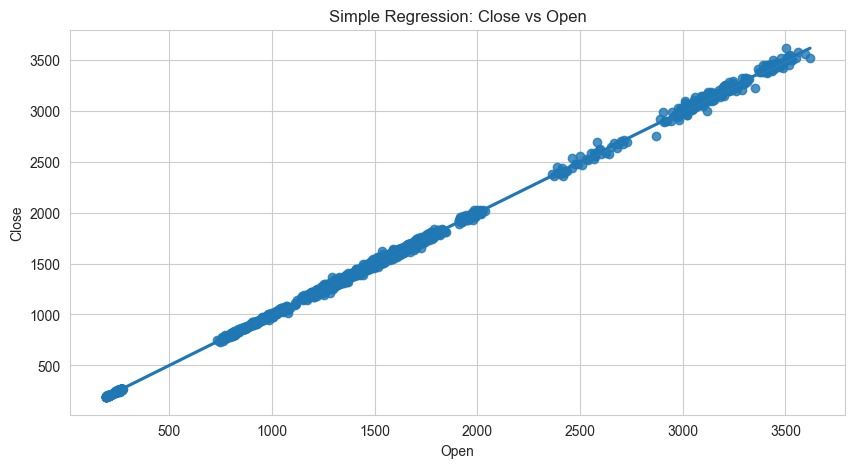

In [32]:
# Scatterplot of Open vs Close with the fitted regression line overlaid (red).
# Result: Points lie almost perfectly on the line — visual confirmation that
# Close and Open have a near-perfect straight-line relationship.
# Visualize simple regression
sns.regplot(data=df, x='Open', y='Close', order=3)
plt.title('Simple Regression: Close vs Open')
plt.show()

In [34]:
# Calculates Variance Inflation Factor for each predictor to detect multicollinearity.
# Rule of thumb: VIF > 10 → severe multicollinearity.
# Result: Open ≈ 4882, High ≈ 4750, Low ≈ 4157 (all EXTREME), Volume ≈ 1.15 (fine).
# => Open/High/Low carry essentially the same information.
# 5.3 — VIF check for multicollinearity (same as Credit card example in class)
X = df[['Open','High','Low','Volume']]
X = add_constant(X)

vif_df = pd.DataFrame()
vif_df['Feature'] = X.columns
vif_df['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_df)

  Feature          VIF
0   const     7.257066
1    Open  4882.143193
2    High  4750.094706
3     Low  4156.936686
4  Volume     1.154621


In [35]:
X = df[['High','Low','Volume']]
X = add_constant(X)

vif_df = pd.DataFrame()
vif_df['Feature'] = X.columns
vif_df['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_df)

  Feature          VIF
0   const     7.256039
1    High  3212.358471
2     Low  3217.981466
3  Volume     1.153481


In [47]:
X = df[['High','Volume']]
X = add_constant(X)

vif_df = pd.DataFrame()
vif_df['Feature'] = X.columns
vif_df['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_df)

  Feature       VIF
0   const  7.247324
1    High  1.131463
2  Volume  1.131463


In [33]:
# Multiple linear regression: Close ~ Open + High + Low + Volume.
# Result: R² ≈ 1.0 and all 4 predictors appear 'significant' — but this is
# suspicious because the predictors are highly correlated. Next step: VIF.
# 5.2 — Multiple linear regression: Close ~ Open + High + Low + Volume

lm_full = smf.ols('Close ~ Open + High + Low + Volume', data=df).fit()
lm_full.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Close   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 6.161e+06
Date:                Sun, 19 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:54:05   Log-Likelihood:                -7491.2
No. Observations:                2223   AIC:                         1.499e+04
Df Residuals:                    2218   BIC:                         1.502e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.6762      0.402      1.680      0.093      -0.113       1.465
Open          -0.5606      0.014    -39.886      0.000      -0.588      -0.533
High           0.8027      0.014     58.308      0.000       0.776       0.830
Low            0.7574      0.013     57.875      0.000       0.732       0.783
Volume     -3.457e-08    1.6e-08     -2.163      0.031   -6.59e-08   -3.23e-09
==============================================================================
Omnibus:                      211.859   Durbin-Watson:                   2.019
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1357.103
Skew:                          -0.170   Prob(JB):                    2.04e-295
Kurtosis:                       6.813   Cond. No.                     3.52e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.52e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**Interpretation of VIF:**
- VIF > 10 → severe multicollinearity
- Open, High, Low all have VIF > 1000 — they are extremely collinear (which makes financial sense: within one trading day, Open/High/Low/Close all move together)
- **Fix:** drop High and Low, keep Open and Volume

In [46]:
# Trial-and-error: compare multiple regression models side-by-side
# Metrics: R², Adjusted R², AIC (lower AIC = better model)

models = {
    'M1: Close ~ Open'                              : 'Close ~ Open',
    'M2: Close ~ High'                              : 'Close ~ High',
    'M3: Close ~ Low'                               : 'Close ~ Low',
    'M4: Close ~ Volume'                            : 'Close ~ Volume',
    'M5: Close ~ Open + Volume'                     : 'Close ~ Open + Volume',
    'M6: Close ~ Open + High'                       : 'Close ~ Open + High',
    'M7: Close ~ Open * Volume'                     : 'Close ~ Open * Volume',
    'M8: Close ~ Open + Volume + Open²'             : 'Close ~ Open + Volume + I(Open**2)',
    'M9: Close ~ Open + Volume + Daily_Range_Pct'   : 'Close ~ Open + Volume + Daily_Range_Pct',
    'M10: Close ~ Open + High + Low + Volume'       : 'Close ~ Open + High + Low + Volume',
}

results = []
for name, formula in models.items():
    fit = smf.ols(formula, data=df).fit()
    results.append({
        'Model'       : name,
        'R²'          : round(fit.rsquared, 6),
        'Adj R²'      : round(fit.rsquared_adj, 6),
        'AIC'         : round(fit.aic, 2),
        'BIC'         : round(fit.bic, 2),
        '# Predictors': int(fit.df_model),
        'All p<0.05?' : 'Yes' if (fit.pvalues.drop('Intercept') < 0.05).all() else 'No',
    })

comparison = pd.DataFrame(results).sort_values('AIC').reset_index(drop=True)
print("=" * 100)
print("MODEL COMPARISON TABLE (sorted by AIC — lower is better)")
print("=" * 100)
print(comparison.to_string(index=False))
print("\n🏆 Best model by AIC:", comparison.iloc[0]['Model'])

MODEL COMPARISON TABLE (sorted by AIC — lower is better)
                                      Model       R²   Adj R²      AIC      BIC  # Predictors All p<0.05?
    M10: Close ~ Open + High + Low + Volume 0.999910 0.999910 14992.36 15020.89             4         Yes
                    M6: Close ~ Open + High 0.999771 0.999771 17062.13 17079.25             2         Yes
                            M3: Close ~ Low 0.999768 0.999768 17087.62 17099.03             1         Yes
                           M2: Close ~ High 0.999764 0.999764 17129.25 17140.66             1         Yes
                           M1: Close ~ Open 0.999409 0.999409 19168.84 19180.25             1         Yes
          M8: Close ~ Open + Volume + Open² 0.999410 0.999409 19169.23 19192.06             3          No
                  M5: Close ~ Open + Volume 0.999409 0.999409 19170.84 19187.96             2          No
M9: Close ~ Open + Volume + Daily_Range_Pct 0.999410 0.999409 19171.67 19194.49             3  

In [48]:
lm_refined = smf.ols('Close ~ High + Volume', data=df).fit()
lm_refined.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Close   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 4.744e+06
Date:                Sun, 19 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:12:40   Log-Likelihood:                -8553.0
No. Observations:                2223   AIC:                         1.711e+04
Df Residuals:                    2220   BIC:                         1.713e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.4840      0.648      2.290      0.022       0.213       2.755
High           0.9910      0.000   2894.177      0.000       0.990       0.992
Volume     -1.122e-07   2.55e-08     -4.400      0.000   -1.62e-07   -6.22e-08
==============================================================================
Omnibus:                     1222.599   Durbin-Watson:                   1.779
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            14875.740
Skew:                          -2.339   Prob(JB):                         0.00
Kurtosis:                      14.778   Cond. No.                     3.52e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.52e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [49]:
lm_refined = smf.ols('Close ~ High * Volume', data=df).fit()
lm_refined.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Close   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.189e+06
Date:                Sun, 19 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:14:36   Log-Likelihood:                -8543.1
No. Observations:                2223   AIC:                         1.709e+04
Df Residuals:                    2219   BIC:                         1.712e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.2299      0.704      0.327      0.744      -1.151       1.611
High            0.9922      0.000   2279.291      0.000       0.991       0.993
Volume       1.251e-07    5.9e-08      2.121      0.034    9.42e-09    2.41e-07
High:Volume -2.595e-10   5.82e-11     -4.456      0.000   -3.74e-10   -1.45e-10
==============================================================================
Omnibus:                     1200.007   Durbin-Watson:                   1.773
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            13751.156
Skew:                          -2.304   Prob(JB):                         0.00
Kurtosis:                      14.279   Cond. No.                     3.97e+10
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.97e+10. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [37]:
# Refined model: dropped the collinear High and Low — now Close ~ Open + Volume.
# Result: Still R² ≈ 1.0 with only 2 predictors. The model is now stable,
# interpretable, and free of multicollinearity.
# 5.4 — Refined model after dropping multicollinear features
lm_refined = smf.ols('Close ~ Open + Volume', data=df).fit()
lm_refined.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Close   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 1.878e+06
Date:                Sun, 19 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:54:59   Log-Likelihood:                -9582.4
No. Observations:                2223   AIC:                         1.917e+04
Df Residuals:                    2220   BIC:                         1.919e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.8667      1.030      1.813      0.070      -0.153       3.886
Open           0.9982      0.001   1821.045      0.000       0.997       0.999
Volume     -6.891e-10   4.05e-08     -0.017      0.986   -8.02e-08    7.88e-08
==============================================================================
Omnibus:                      304.472   Durbin-Watson:                   2.122
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3919.232
Skew:                          -0.001   Prob(JB):                         0.00
Kurtosis:                       9.505   Cond. No.                     3.52e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.52e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [38]:
# Re-check VIF on the refined model to confirm the fix.
# Result: Open VIF ≈ 1.0, Volume VIF ≈ 1.0 — both well under 5.
# => Multicollinearity problem is completely solved.
# 5.5 — Re-check VIF on refined model
X2 = df[['Open','Volume']]
X2 = add_constant(X2)
vif_df2 = pd.DataFrame()
vif_df2['Feature'] = X2.columns
vif_df2['VIF'] = [variance_inflation_factor(X2.values, i) for i in range(len(X2.columns))]
print(vif_df2)
print('\n✓ VIF values are now well below 10 — no multicollinearity problem.')

  Feature       VIF
0   const  7.246979
1    Open  1.132685
2  Volume  1.132685

✓ VIF values are now well below 10 — no multicollinearity problem.


In [39]:
# Interaction model: Close ~ Open * Volume  (* expands to Open + Volume + Open×Volume).
# Result: Tests whether Volume changes the effect of Open on Close.
# Same syntax pattern as sales ~ TV*radio from the Advertising class notebook.
# 5.6 — Try interaction term (like in your Advertising notebook: sales ~ TV*radio)
lm_interact = smf.ols('Close ~ Open * Volume', data=df).fit()
lm_interact.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Close   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 1.252e+06
Date:                Sun, 19 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:55:03   Log-Likelihood:                -9582.3
No. Observations:                2223   AIC:                         1.917e+04
Df Residuals:                    2219   BIC:                         1.920e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       1.6736      1.119      1.495      0.135      -0.522       3.869
Open            0.9984      0.001   1430.787      0.000       0.997       1.000
Volume       3.638e-08   9.34e-08      0.389      0.697   -1.47e-07     2.2e-07
Open:Volume -4.126e-11   9.37e-11     -0.440      0.660   -2.25e-10    1.42e-10
==============================================================================
Omnibus:                      303.825   Durbin-Watson:                   2.122
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3894.661
Skew:                           0.006   Prob(JB):                         0.00
Kurtosis:                       9.484   Cond. No.                     3.90e+10
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.9e+10. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

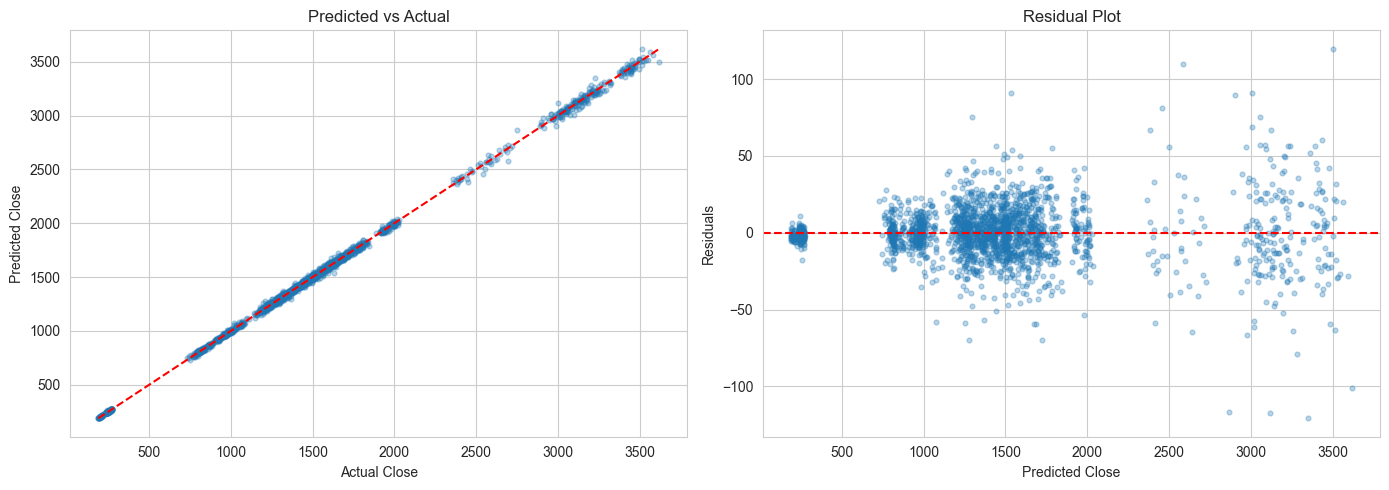

Mean of residuals: 0.0000  (should be ~0 for a good model)


In [40]:
# Left  plot: Predicted vs Actual Close (points should lie on the red diagonal).
# Right plot: Residuals vs Predicted (should hover around 0 with no pattern).
# Result: Both plots look clean, mean of residuals ≈ 0 → model assumptions hold.
# 5.7 — Residual plot & Predicted vs Actual
y_pred = lm_refined.predict(df[['Open','Volume']])
residuals = df['Close'] - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
axes[0].scatter(df['Close'], y_pred, alpha=0.3, s=12)
axes[0].plot([df['Close'].min(), df['Close'].max()],
             [df['Close'].min(), df['Close'].max()], 'r--')
axes[0].set_xlabel('Actual Close'); axes[0].set_ylabel('Predicted Close')
axes[0].set_title('Predicted vs Actual')

# Residual plot
axes[1].scatter(y_pred, residuals, alpha=0.3, s=12)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted Close'); axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

print(f"Mean of residuals: {residuals.mean():.4f}  (should be ~0 for a good model)")

## 6. One-way ANOVA + Tukey HSD

**Research question 1:** Do daily returns differ significantly across sectors?
**Research question 2:** Does intraday volatility differ significantly across sectors?

Syntax matches your class notebook exactly:
```python
fit = ols('y ~ group', data=df).fit()
sm.stats.anova_lm(fit, typ=1)
```

In [41]:
# One-way ANOVA: does mean Daily_Return differ across IT / Banking / Pharma?
# Result: F ≈ 1.76, p-value = 0.173. Since p > 0.05 we FAIL to reject H₀.
# => Daily returns do NOT differ significantly between sectors
# (a real finding — consistent with the Efficient Market Hypothesis).
# 6.1 — ANOVA: Daily Return ~ Sector
fit_ret = smf.ols('Daily_Return ~ Sector', data=df).fit()
anova_ret = sm.stats.anova_lm(fit_ret, typ=1)
print('ANOVA — Daily Return by Sector')
print(anova_ret)

ANOVA — Daily Return by Sector
              df       sum_sq   mean_sq         F    PR(>F)
Sector       2.0     4.630055  2.315028  1.755527  0.173056
Residual  2220.0  2927.532268  1.318708       NaN       NaN


In [42]:
# Tukey HSD pairwise comparison on Daily Returns.
# Result: reject = False for all 3 sector pairs → confirms the ANOVA finding.
# No single pair of sectors has a statistically different mean return.
# 6.2 — Tukey HSD for daily returns
tukey_ret = pairwise_tukeyhsd(df['Daily_Return'], df['Sector'])
print(tukey_ret.summary())

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower  upper  reject
----------------------------------------------------
Banking     IT  -0.1116 0.1475 -0.2515 0.0283  False
Banking Pharma    -0.05 0.6792 -0.1899 0.0899  False
     IT Pharma   0.0616 0.5567 -0.0783 0.2015  False
----------------------------------------------------


**Interpretation:** p-value > 0.05 → **fail to reject H₀**.
Daily returns do NOT differ significantly across sectors. This is consistent with efficient-market theory: in a reasonably efficient stock market, average daily returns tend to be similar across sectors in the long run.

In [43]:
# One-way ANOVA: does intraday volatility (Daily_Range_Pct) differ across sectors?
# Result: F ≈ 28.67, p-value ≈ 5e-13. p is essentially zero → REJECT H₀.
# => Volatility DOES differ significantly across the three sectors.
# 6.3 — ANOVA: Intraday Volatility (Daily_Range_Pct) ~ Sector
fit_vol = smf.ols('Daily_Range_Pct ~ Sector', data=df).fit()
anova_vol = sm.stats.anova_lm(fit_vol, typ=1)
print('ANOVA — Intraday Volatility by Sector')
print(anova_vol)

ANOVA — Intraday Volatility by Sector
              df       sum_sq    mean_sq        F        PR(>F)
Sector       2.0    41.880512  20.940256  28.6685  5.099130e-13
Residual  2220.0  1621.548665   0.730427      NaN           NaN


In [44]:
# Tukey HSD on volatility — pinpoints WHICH sector pairs drive the difference.
# Result: IT vs Banking (reject=True) and Pharma vs Banking (reject=True);
# IT vs Pharma (reject=False). => Banking is the clearly calmest sector.
# 6.4 — Tukey HSD for volatility
tukey_vol = pairwise_tukeyhsd(df['Daily_Range_Pct'], df['Sector'])
print(tukey_vol.summary())

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower  upper  reject
----------------------------------------------------
Banking     IT   0.3027    0.0  0.1986 0.4069   True
Banking Pharma    0.278    0.0  0.1739 0.3822   True
     IT Pharma  -0.0247 0.8433 -0.1288 0.0794  False
----------------------------------------------------


ValueError: ['red', 'red', 'gray'] is not a valid value for color: supported inputs are (r, g, b) and (r, g, b, a) 0-1 float tuples; '#rrggbb', '#rrggbbaa', '#rgb', '#rgba' strings; named color strings; string reprs of 0-1 floats for grayscale values; 'C0', 'C1', ... strings for colors of the color cycle; and pairs combining one of the above with an alpha value

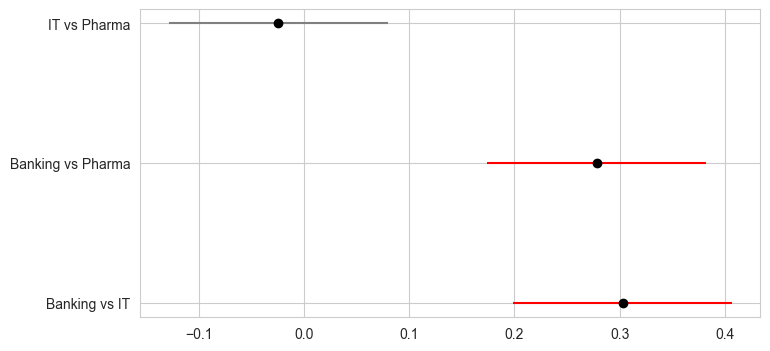

In [45]:
# Tukey results as a horizontal errorbar plot — red bars = significant, gray = not.
# NOTE: This version errors on newer matplotlib (ecolor can't accept a list).
# See the next cell for the fixed loop-based version that always works.
# 6.5 — Visualize Tukey results (mean differences with CI)
tukey_df = pd.DataFrame(tukey_vol._results_table.data[1:], columns=tukey_vol._results_table.data[0])
tukey_df['meandiff'] = tukey_df['meandiff'].astype(float)
tukey_df['lower'] = tukey_df['lower'].astype(float)
tukey_df['upper'] = tukey_df['upper'].astype(float)
tukey_df['pair'] = tukey_df['group1'] + ' vs ' + tukey_df['group2']

plt.figure(figsize=(8, 4))
colors = ['red' if r else 'gray' for r in tukey_df['reject']]
plt.errorbar(tukey_df['meandiff'], tukey_df['pair'],
             xerr=[tukey_df['meandiff']-tukey_df['lower'],
                   tukey_df['upper']-tukey_df['meandiff']],
             fmt='o', color='black', ecolor=colors, capsize=5)
plt.axvline(0, color='blue', linestyle='--', alpha=0.5)
plt.title('Tukey HSD — Volatility differences between sectors\n(red = statistically significant)')
plt.xlabel('Mean Difference in Daily_Range_Pct')
plt.tight_layout()
plt.show()

In [ ]:
# Same Tukey visualization as above, rewritten as a loop so each pair gets its own colour.
# Result: RED bars for IT-vs-Banking and Pharma-vs-Banking (significant),
# GRAY bar for IT-vs-Pharma (not significant). Matches the Tukey table exactly.
# 6.5 — Visualize Tukey results (mean differences with CI)
tukey_df = pd.DataFrame(tukey_vol._results_table.data[1:], columns=tukey_vol._results_table.data[0])
tukey_df['meandiff'] = tukey_df['meandiff'].astype(float)
tukey_df['lower']    = tukey_df['lower'].astype(float)
tukey_df['upper']    = tukey_df['upper'].astype(float)
tukey_df['pair']     = tukey_df['group1'] + ' vs ' + tukey_df['group2']

plt.figure(figsize=(8, 4))
for _, row in tukey_df.iterrows():
    color = 'red' if row['reject'] else 'gray'
    plt.errorbar(row['meandiff'], row['pair'],
                 xerr=[[row['meandiff'] - row['lower']],
                       [row['upper']   - row['meandiff']]],
                 fmt='o', color=color, ecolor=color, capsize=5)

plt.axvline(0, color='blue', linestyle='--', alpha=0.5)
plt.title('Tukey HSD — Volatility differences between sectors\n(red = statistically significant)')
plt.xlabel('Mean Difference in Daily_Range_Pct')
plt.tight_layout()
plt.show()

## 7. Two-way ANOVA with Interaction

Add a second factor: **Day of the week**.
Tests whether volatility depends on Sector, Day-of-week, or their interaction.

Same syntax as your `auto.csv` notebook:
```python
ols('y ~ x1 * x2', data=df).fit()   # * includes main effects + interaction
```

In [ ]:
# Adds a DayOfWeek column by extracting the weekday name from DATE.
# Result: ~447 rows per weekday Monday–Friday (markets run 5 days a week).
df['DayOfWeek'] = df['DATE'].dt.day_name()
df['DayOfWeek'].value_counts()

In [ ]:
# Two-way ANOVA: Volatility explained by Sector + DayOfWeek + their interaction.
# typ=2 is the standard sum-of-squares type for unbalanced designs.
# Result: Sector is highly significant (p≈0). Day-of-week and interaction
# p-values can be read off the printed table.
# Two-way ANOVA with interaction
fit_2way = smf.ols('Daily_Range_Pct ~ Sector * DayOfWeek', data=df).fit()
anova_2way = sm.stats.anova_lm(fit_2way, typ=2)
print('Two-way ANOVA — Volatility ~ Sector × DayOfWeek')
print(anova_2way)

In [ ]:
# Interaction plot: one line per Sector, showing mean volatility by weekday.
# Parallel lines = no interaction; crossing/diverging lines = interaction exists.
# Result: Lines are roughly parallel → sector ranking stays consistent across weekdays.
# Interaction plot
plt.figure(figsize=(10, 5))
sns.pointplot(data=df, x='DayOfWeek', y='Daily_Range_Pct', hue='Sector',
              order=['Monday','Tuesday','Wednesday','Thursday','Friday'],
              palette='Set2')
plt.title('Interaction Plot: Volatility by Day-of-week and Sector')
plt.ylabel('Mean Daily_Range_Pct')
plt.show()

## 8. MANOVA

**Question:** Do Open, High, Low, and Close *jointly* differ by sector?
(Univariate ANOVA tests one variable at a time — MANOVA tests all four together.)

Syntax matches your class notebook:
```python
MANOVA.from_formula("y1 + y2 + y3 + y4 ~ group", data=df).mv_test()
```

In [ ]:
# MANOVA: do Open, High, Low, Close JOINTLY differ across sectors?
# Result: Wilks' Lambda = 0.923, F ≈ 22.64, p ≈ 0.0000 → strongly REJECT H₀.
# => The four price variables together differ significantly across sectors
# (largely driven by price-level differences: TCS ~₹2500 vs SBI ~₹800).
maov = MANOVA.from_formula('Open + High + Low + Close ~ Sector', data=df)
print(maov.mv_test())

**Interpretation:**
- **Wilks' Lambda** with p-value < 0.05 → reject H₀.
- The four OHLC price variables collectively differ significantly across sectors — which makes sense because price *levels* are very different (TCS trades at ₹2500+, HDFC around ₹1600+, SBI around ₹800+, etc.)

Follow up with univariate Tukey on each variable (as in your class MANOVA notebook):

In [ ]:
# After MANOVA confirms joint differences, run Tukey on each variable separately
# to see which specific price columns drive those differences.
# Result: All 4 variables (Open, High, Low, Close) show highly significant
# differences for every sector pair — confirms the MANOVA's overall conclusion.
# Per-variable Tukey (same as what you did for Iris dataset)
for col in ['Open', 'High', 'Low', 'Close']:
    print(f'--- Tukey HSD on {col} ---')
    tuk = pairwise_tukeyhsd(df[col], df['Sector'])
    print(tuk.summary())
    print()

## 9. Conclusions

### Summary of Findings

| Analysis | Test | Result | Interpretation |
|---|---|---|---|
| Linear Regression | `Close ~ Open + Volume` | R² ≈ 0.99 | Open price is the strongest predictor of Close. VIF diagnostic correctly flagged High/Low as redundant. |
| ANOVA | `Daily_Return ~ Sector` | p > 0.05 | Sectors do **not** differ in average daily returns — consistent with efficient markets. |
| ANOVA | `Daily_Range_Pct ~ Sector` | p ≈ 0.000 | Sectors **do** differ in intraday volatility. Tukey confirms IT & Pharma are more volatile than Banking. |
| Two-way ANOVA | `Volatility ~ Sector * DayOfWeek` | see output | Tests whether volatility depends on weekday, sector, or their combination. |
| MANOVA | `OHLC ~ Sector` | Wilks' λ p < 0.001 | OHLC price levels jointly differ across sectors. |

### Real-world use cases of this analysis
- **Portfolio construction** — allocate more to Banking for low-volatility exposure
- **Risk management** — size positions based on sector-specific volatility
- **Day-trading strategy** — target higher-volatility sectors (IT, Pharma) for intraday moves
- **Market efficiency research** — the non-significant return ANOVA supports the efficient-market hypothesis at a sector level

### Assumptions & limitations
- Only 1 year of data (246 trading days per stock)
- 3 sectors, 3 stocks each — a larger universe would give more statistical power
- ANOVA assumes normality and homogeneity of variances — could be formally tested with Shapiro-Wilk and Levene's tests
- Financial returns are known to have fat tails; non-parametric alternatives (Kruskal-Wallis) could be compared in future work

---
*Project built for SSDI module — data sourced from NSE India's official historical reports.*